# Airline Loyalty Program: Business Insights & Executive Dashboard

## Objective

This notebook summarizes the key findings from the airline loyalty analytics project. It combines insights from exploratory data analysis, customer segmentation, and churn prediction to provide actionable business recommendations.

The goal is to translate technical analysis into business strategies that improve customer retention, increase customer lifetime value, and enhance the overall effectiveness of the airline's loyalty program.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("customer_segments.csv")

In [3]:
df.shape

(16737, 18)

In [4]:
df.describe()

,Loyalty Number,Total Flights,Total Distance,Total Points Earned,Total Points Redeemed,Active Months,Avg Flights per Active Month,Redemption Ratio,Avg Distance per Flight,Enrollment Year,Enrollment Month,Loyalty Tenure (Months),Months Since Last Flight,Churn,At Risk,Cluster
count,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,15167.000000,15167.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,15167.000000,16737.000000,16737.000000,16737.000000
mean,549735.880445,30.400191,45579.359921,47592.100884,734.932903,8.638557,3.867168,0.016147,1361.353499,2015.253211,6.669116,38.292346,1.446298,0.123499,0.053713,0.562407
std,258912.132453,16.865558,26092.338663,30391.859064,716.589736,2.813685,1.553721,0.025660,491.079062,1.979111,3.398958,23.605926,3.508961,0.329019,0.225458,0.850819
min,100018.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2012.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,326603.000000,20.000000,28495.000000,28718.000000,0.000000,7.000000,3.090909,0.000000,1306.552632,2014.000000,4.000000,17.000000,0.000000,0.000000,0.000000,0.000000
50%,550434.000000,34.000000,49445.000000,49885.000000,568.000000,9.000000,3.666667,0.011838,1473.711538,2015.000000,7.000000,37.000000,0.000000,0.000000,0.000000,0.000000
75%,772019.000000,42.000000,62911.000000,63812.000000,1167.000000,11.000000,4.250000,0.023417,1620.576923,2017.000000,10.000000,59.000000,1.000000,0.000000,0.000000,1.000000
max,999986.000000,106.000000,178858.000000,268287.000000,4479.000000,12.000000,24.000000,1.194352,2496.000000,2018.000000,12.000000,80.000000,23.000000,1.000000,1.000000,3.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Loyalty Number                16737 non-null  int64  
 1   Total Flights                 16737 non-null  int64  
 2   Total Distance                16737 non-null  int64  
 3   Total Points Earned           16737 non-null  float64
 4   Total Points Redeemed         16737 non-null  int64  
 5   Active Months                 15167 non-null  float64
 6   Avg Flights per Active Month  15167 non-null  float64
 7   Redemption Ratio              16737 non-null  float64
 8   Avg Distance per Flight       16737 non-null  float64
 9   Enrollment Year               16737 non-null  int64  
 10  Enrollment Month              16737 non-null  int64  
 11  Loyalty Tenure (Months)       16737 non-null  int64  
 12  Last Flight Date              15167 non-null  object 
 13  M

In [6]:
df.isnull().sum()

,0
Loyalty Number,0
Total Flights,0
Total Distance,0
Total Points Earned,0
Total Points Redeemed,0
Active Months,1570
Avg Flights per Active Month,1570
Redemption Ratio,0
Avg Distance per Flight,0
Enrollment Year,0


# Executive Dashboard

The following KPIs provide an overview of the airline loyalty program's current customer base and engagement levels.

In [7]:
total_customers = len(df)

print("Total Customers:", total_customers)

Total Customers: 16737


In [8]:
active_customers = (df["Total Flights"] > 0).sum()

print("Active Customers:", active_customers)

Active Customers: 15167


In [9]:
inactive_customers = (df["Total Flights"] == 0).sum()

print("Inactive Customers:", inactive_customers)

Inactive Customers: 1570


In [10]:
churn_rate = df["Churn"].mean()*100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 12.35%


In [11]:
at_risk = df["At Risk"].sum()

print("At Risk Customers:", at_risk)

At Risk Customers: 899


In [12]:
avg_flights = df["Total Flights"].mean()

print(f"Average Flights: {avg_flights:.2f}")

Average Flights: 30.40


In [13]:
avg_tenure = df["Loyalty Tenure (Months)"].mean()

print(f"Average Loyalty Tenure: {avg_tenure:.2f} months")

Average Loyalty Tenure: 38.29 months


In [14]:
avg_redemption = df["Redemption Ratio"].mean()

print(f"Average Redemption Ratio: {avg_redemption:.4f}")

Average Redemption Ratio: 0.0161


In [15]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Active Customers",
        "Inactive Customers",
        "Churn Rate (%)",
        "At-Risk Customers",
        "Average Flights",
        "Average Loyalty Tenure (Months)",
        "Average Redemption Ratio"
    ],
    "Value": [
        total_customers,
        active_customers,
        inactive_customers,
        round(churn_rate,2),
        at_risk,
        round(avg_flights,2),
        round(avg_tenure,2),
        round(avg_redemption,4)
    ]
})

kpi_summary

,Metric,Value
0,Total Customers,16737.0000
1,Active Customers,15167.0000
2,Inactive Customers,1570.0000
3,Churn Rate (%),12.3500
4,At-Risk Customers,899.0000
5,Average Flights,30.4000
6,Average Loyalty Tenure (Months),38.2900
7,Average Redemption Ratio,0.0161


## Executive KPI Summary

The airline loyalty program consists of **16,737 customers**, of which **15,167 (90.6%)** have completed at least one flight. The remaining **1,570 customers (9.4%)** have never flown, representing an opportunity for customer activation campaigns.

The overall **churn rate is 12.35%**, indicating that approximately one out of every eight customers has cancelled their loyalty membership. Additionally, **899 customers are currently classified as at-risk**, highlighting a segment that should be prioritized for proactive retention efforts.

On average, customers have completed **30.4 flights** and have remained in the loyalty program for **38.29 months**, demonstrating a relatively long customer relationship. The average redemption ratio of **1.61%** suggests that only a small proportion of earned loyalty points are redeemed, presenting opportunities to improve customer engagement through enhanced reward utilization.

# Customer Segment Analysis

Customer segmentation groups loyalty members based on their travel behavior and engagement.

Understanding these segments enables the airline to design personalized marketing strategies, improve customer experience, and maximize customer lifetime value.

In [17]:
# Customer Segment By Distribution
segment_counts = (
    df["Customer Segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["Customer Segment", "Customers"]

segment_counts

,Customer Segment,Customers
0,Loyal Frequent Travelers,10529
1,Growing Customers,3796
2,Inactive Members,1619
3,High-Engagement New Travelers,793


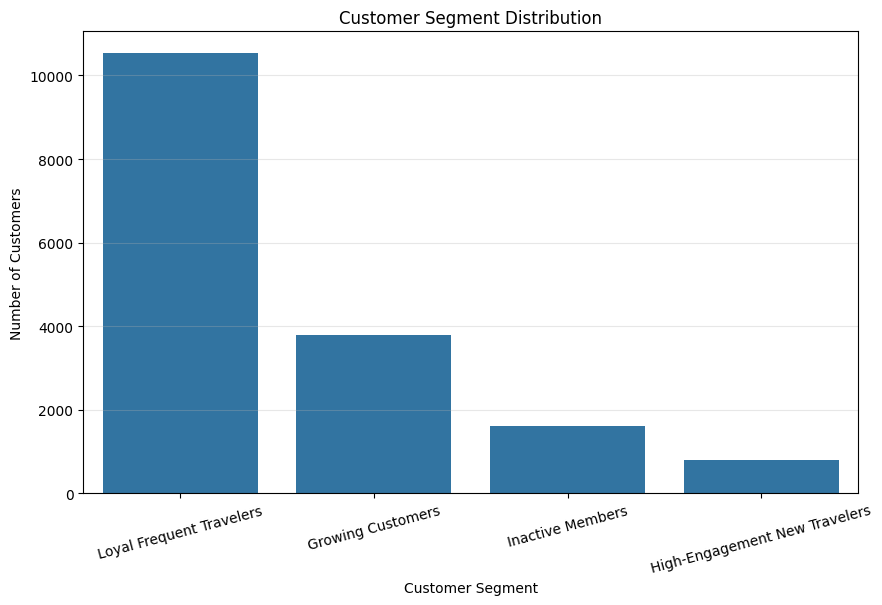

In [18]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Customer Segment",
    order=df["Customer Segment"].value_counts().index
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.grid(axis="y", alpha=0.3)

plt.show()

In [19]:
#Average Flights By Segment
avg_flights_segment = (
    df.groupby("Customer Segment")["Total Flights"]
    .mean()
    .sort_values(ascending=False)
)

avg_flights_segment

,Total Flights
Customer Segment,
High-Engagement New Travelers,55.080706
Loyal Frequent Travelers,38.694463
Growing Customers,15.179926
Inactive Members,0.056825


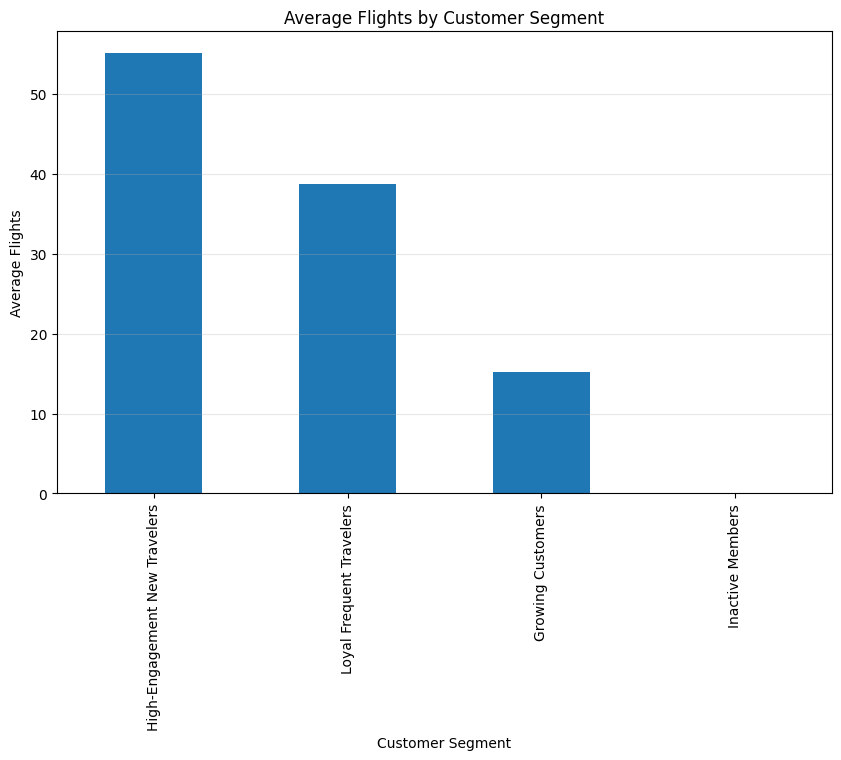

In [20]:
plt.figure(figsize=(10,6))

avg_flights_segment.plot(kind="bar")

plt.title("Average Flights by Customer Segment")

plt.ylabel("Average Flights")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [21]:
#Loyalty Tenure By Segments
avg_tenure_segment = (
    df.groupby("Customer Segment")["Loyalty Tenure (Months)"]
    .mean()
    .sort_values(ascending=False)
)

avg_tenure_segment

,Loyalty Tenure (Months)
Customer Segment,
Loyal Frequent Travelers,48.233450
Inactive Members,40.968499
Growing Customers,15.443888
High-Engagement New Travelers,10.209332


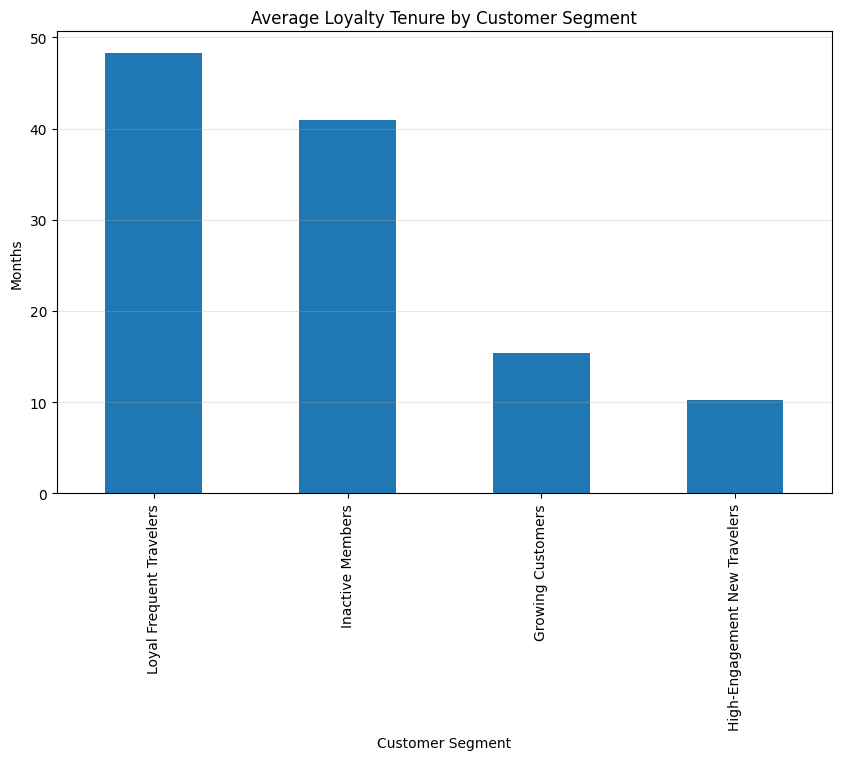

In [22]:
plt.figure(figsize=(10,6))

avg_tenure_segment.plot(kind="bar")

plt.title("Average Loyalty Tenure by Customer Segment")

plt.ylabel("Months")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [23]:
#Churn Rate By Segments
churn_segment = (
    df.groupby("Customer Segment")["Churn"]
    .mean() * 100
).sort_values(ascending=False)

churn_segment

,Churn
Customer Segment,
Inactive Members,59.975293
Growing Customers,21.232877
High-Engagement New Travelers,10.592686
Loyal Frequent Travelers,1.956501


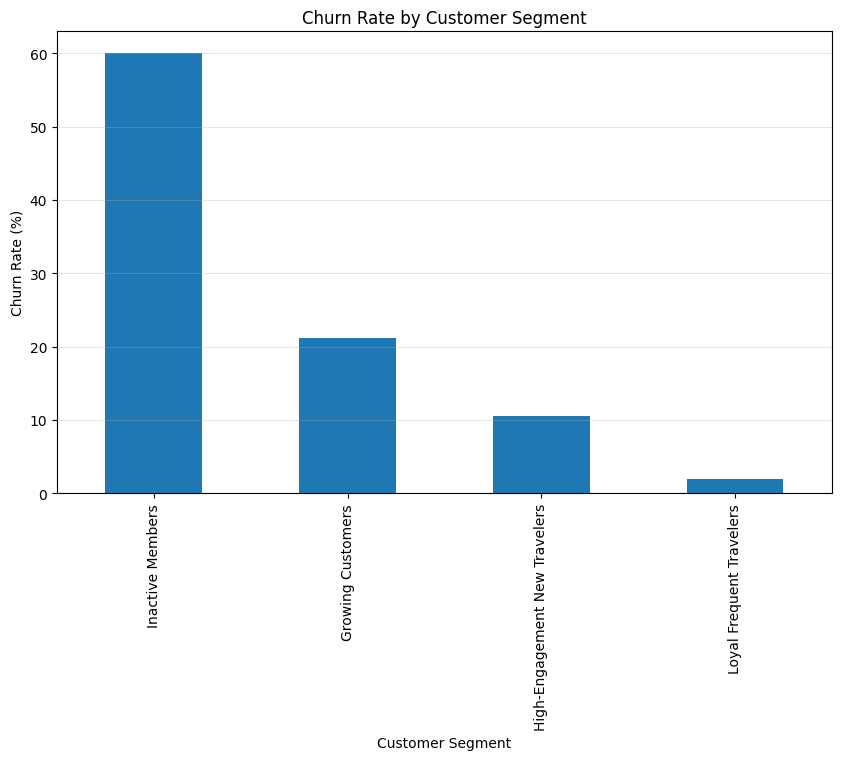

In [24]:
plt.figure(figsize=(10,6))

churn_segment.plot(kind="bar")

plt.ylabel("Churn Rate (%)")

plt.title("Churn Rate by Customer Segment")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Customer Distribution

The majority of customers (62.9%) belong to the **Loyal Frequent Travelers** segment, indicating a strong and engaged customer base.

Approximately 22.7% of customers are classified as **Growing Customers**, representing an important opportunity to strengthen long-term loyalty.

Although **Inactive Members** represent less than 10% of customers, they require immediate attention because they contribute disproportionately to customer churn.

The **High-Engagement New Travelers** segment is relatively small but highly valuable due to its exceptional travel activity despite a short loyalty tenure.

### Travel Activity

The **High-Engagement New Travelers** segment records the highest average number of flights (55.08), demonstrating exceptional engagement shortly after joining the loyalty program.

The **Loyal Frequent Travelers** segment averages nearly 39 flights, reflecting consistent travel behavior over a longer period.

Growing Customers travel less frequently but represent a promising customer group with potential for increased engagement.

Inactive Members rarely travel, averaging fewer than one flight, indicating extremely low participation in the loyalty program.

### Loyalty Tenure

The **Loyal Frequent Travelers** segment has the longest average loyalty tenure (48.23 months), indicating strong long-term relationships with the airline.

Inactive Members have remained enrolled for almost 41 months despite very limited travel activity, suggesting many customers retain membership without actively engaging.

Growing Customers and High-Engagement New Travelers have shorter loyalty histories, making them important targets for customer development initiatives.

### Churn Analysis

The **Inactive Members** segment exhibits the highest churn rate (59.98%), making it the airline's highest-risk customer group.

Growing Customers experience a churn rate of 21.23%, suggesting that customers in the early stages of their loyalty journey require additional engagement and retention efforts.

High-Engagement New Travelers maintain a relatively low churn rate (10.59%), demonstrating that highly active customers are less likely to cancel.

The Loyal Frequent Travelers segment records the lowest churn rate (1.96%), confirming that consistent engagement significantly improves customer retention.

# Business Recommendations

## Loyal Frequent Travelers
- Offer exclusive loyalty rewards and premium membership benefits.
- Provide priority boarding, lounge access, and personalized travel offers.
- Reward long-term loyalty through tier upgrades.

## Growing Customers
- Encourage repeat travel using bonus miles and personalized promotions.
- Recommend complementary services such as hotel partnerships and travel packages.
- Increase engagement through milestone-based loyalty rewards.

## Inactive Members
- Launch targeted reactivation campaigns.
- Offer limited-time bonus points and discounted fares.
- Send personalized reminders highlighting unused loyalty benefits.

## High-Engagement New Travelers
- Fast-track premium loyalty status.
- Promote premium credit cards and business travel packages.
- Maintain engagement through exclusive early-access offers.

# Executive Summary

This project combined exploratory data analysis, feature engineering, customer segmentation, and machine learning to better understand airline loyalty program behavior.

## Key Findings

- The loyalty program contains **16,737 customers**, with over **90% actively using airline services**.
- Customer churn is concentrated within inactive and low-engagement customer groups.
- Four distinct customer segments were identified using K-Means clustering, each requiring different engagement strategies.
- The Decision Tree model achieved **98.15% accuracy** in predicting customer churn.
- Customer inactivity, measured through **Months Since Last Flight**, emerged as the strongest predictor of churn.

## Strategic Recommendations

- Prioritize retention campaigns for inactive members.
- Reward loyal frequent travelers with premium benefits.
- Develop personalized engagement strategies for growing customers.
- Fast-track loyalty upgrades for highly engaged new travelers.
- Integrate the churn prediction model into customer relationship management systems to proactively identify customers at risk.